#### 회원 성별/나이별과 월별 가입자에 대한 그래프 
#### 전체회원, 남성, 여성
#### 월별 가입자수 - 표식 누적이 있는 꺾은선(범례:나이대,성별 - 범주:가입일 - 값 : 가입월 개) - member / join 필요없음

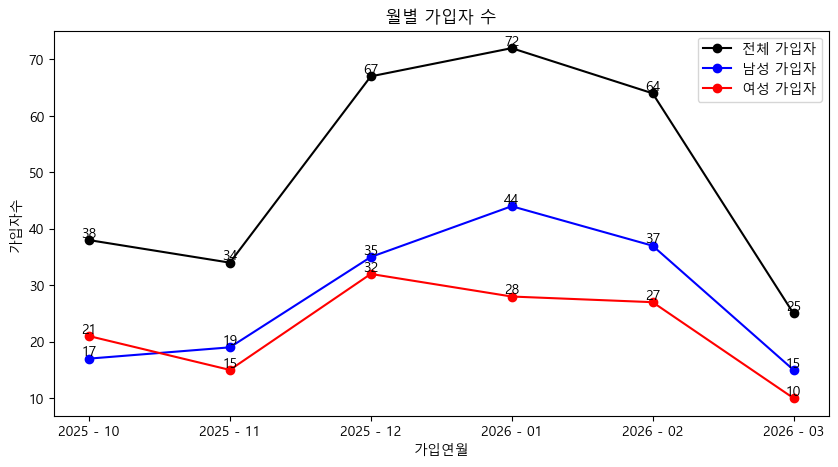

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('greenData/resort/member.csv', encoding='utf-8-sig')
df2 = pd.DataFrame(df)
df2 = df2[df2["m_nickName"] != "admin"] # 관리자 제외

# m_regDate를 날짜형식으로 변경
df2['m_regDate'] = pd.to_datetime(df2['m_regDate'])

df2['가입연월'] = df2['m_regDate'].dt.strftime('%Y - %m')

manCount = df2[df2["m_gender"] == 0]
womanCount = df2[df2["m_gender"] == 1]

result = df2.groupby('가입연월')['m_code'].count().reset_index() # 전체 가입자
result01 = manCount.groupby('가입연월')['m_code'].count().reset_index() # 남성 가입자수 167
result02 = womanCount.groupby('가입연월')['m_code'].count().reset_index() # 여성 가입자수 133

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,5))
plt.plot(result['가입연월'], result['m_code'], marker = 'o', color='black', label='전체 가입자')
plt.plot(result01['가입연월'], result01['m_code'], marker = 'o', color='blue', label='남성 가입자')
plt.plot(result02['가입연월'], result02['m_code'], marker = 'o', color='red', label='여성 가입자')

for i in range(len(result['m_code'])):
    v1 = result['m_code'][i]
    v2 = result01['m_code'][i]
    v3 = result02['m_code'][i]
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v1,             # y의 위치 (막대 높이) 
        int(v1),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v2,             # y의 위치 (막대 높이) 
        int(v2),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v3,             # y의 위치 (막대 높이) 
        int(v3),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("월별 가입자 수")
plt.xlabel("가입연월")
plt.ylabel("가입자수")

plt.legend()

plt.show()

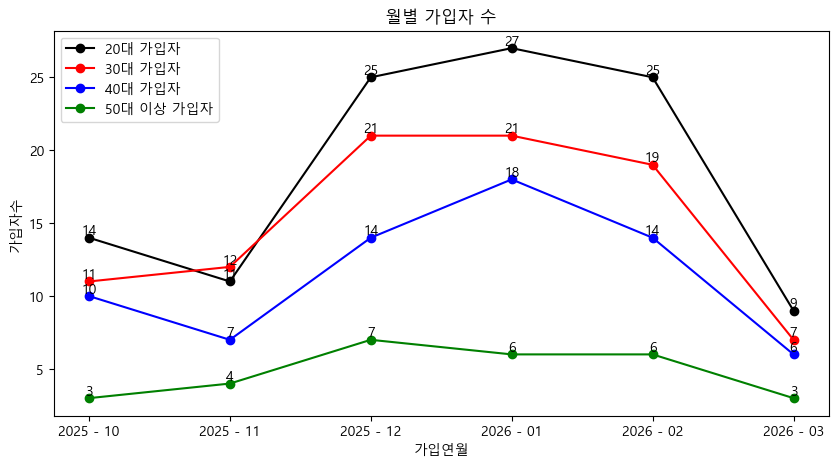

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('greenData/resort/member.csv', encoding='utf-8-sig')
df2 = pd.DataFrame(df)
df2 = df2[df2["m_nickName"] != "admin"] # 관리자 제외

# m_regDate를 날짜형식으로 변경
df2['m_regDate'] = pd.to_datetime(df2['m_regDate'])

df2['가입연월'] = df2['m_regDate'].dt.strftime('%Y - %m')

df2.loc[(df2['m_birth']>='1966-01-01') & (df2['m_birth']<'1976-01-01'),'나이대'] = 50
df2.loc[(df2['m_birth']>='1976-01-01') & (df2['m_birth']<'1986-01-01'),'나이대'] = 40
df2.loc[(df2['m_birth']>='1986-01-01') & (df2['m_birth']<'1996-01-01'),'나이대'] = 30
df2.loc[(df2['m_birth']>='1996-01-01') & (df2['m_birth']<'2006-01-01'),'나이대'] = 20

df20 = df2[df2['나이대'] == 20]
df30 = df2[df2['나이대'] == 30]
df40 = df2[df2['나이대'] == 40]
df50 = df2[df2['나이대'] == 50]

df50

result20 = df20.groupby('가입연월')['m_code'].count().reset_index() # 20대 가입자
result30 = df30.groupby('가입연월')['m_code'].count().reset_index() # 30대 가입자
result40 = df40.groupby('가입연월')['m_code'].count().reset_index() # 40대 가입자
result50 = df50.groupby('가입연월')['m_code'].count().reset_index() # 50대이상 가입자
result20

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,5))
plt.plot(result20['가입연월'], result20['m_code'], marker = 'o', color='black', label='20대 가입자')
plt.plot(result30['가입연월'], result30['m_code'], marker = 'o', color='red', label='30대 가입자')
plt.plot(result40['가입연월'], result40['m_code'], marker = 'o', color='blue', label='40대 가입자')
plt.plot(result50['가입연월'], result50['m_code'], marker = 'o', color='green', label='50대 이상 가입자')

for i in range(len(result20['m_code'])):
    v1 = result20['m_code'][i]
    v2 = result30['m_code'][i]
    v3 = result40['m_code'][i]
    v4 = result50['m_code'][i]
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v1,             # y의 위치 (막대 높이) 
        int(v1),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v2,             # y의 위치 (막대 높이) 
        int(v2),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v3,             # y의 위치 (막대 높이) 
        int(v3),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v4,             # y의 위치 (막대 높이) 
        int(v4),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )
   

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("월별 가입자 수 (나이대)")
plt.xlabel("가입연월")
plt.ylabel("가입자수")

plt.legend()

plt.show()

#### 예약이 많은 시기 - 막대그래프 - x축(월) -  y축(예약 수)

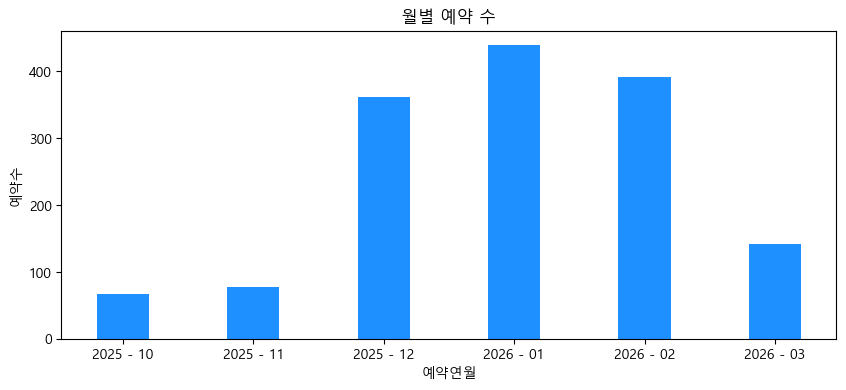

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
df2 = pd.DataFrame(df)
df2 = df2[df2['cancel'] != 1]

# reserved_at를 날짜형식으로 변경
df2['reserved_at'] = pd.to_datetime(df2['reserved_at'])

df2['예약연월'] = df2['reserved_at'].dt.strftime('%Y - %m')

result = df2.groupby('예약연월')['m_code'].count().reset_index()

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,4))

plt.bar(result['예약연월'], result['m_code'], width=0.4, color='dodgerblue')

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("월별 예약 수")
plt.xlabel("예약연월")
plt.ylabel("예약수")

plt.show()

인기있는 호텔 - 도시별 상위 10개

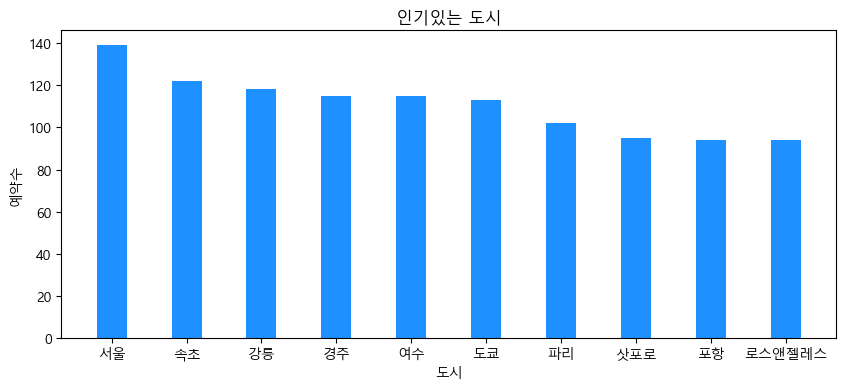

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

re1 = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
re = pd.DataFrame(re1)
ho1 = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8-sig')
ho = pd.DataFrame(ho1)
ro1 = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
ro = pd.DataFrame(ro1)

mergeReRo = pd.merge(re,ro,on='r_code',how='inner')
mergeReRoHo = pd.merge(ho,mergeReRo,on='h_code',how='inner')

mergeReRoHo['도시명'] = mergeReRoHo['city'].map({
    'Seoul': '서울',
    'Busan': '부산',
    'Gangneung': '강릉',
    'Sokcho': '속초',
    'Gyeongju': '경주',
    'Yeosu': '여수',
    'Daejeon': '대전',
    'Gwangju': '광주',
    'Jeju': '제주',
    'Pohang': '포항',
    'Tokyo': '도쿄',
    'Sapporo': '삿포로',
    'LosAngeles': '로스앤젤레스',
    'New York': '뉴욕',
    'Guam': '괌',
    'Zhangjiajie': '장가계',
    'Shanghai': '상하이',
    'Rome': '로마',
    'Venice': '베네치아',
    'Paris': '파리',
})
    
result = mergeReRoHo.groupby('도시명')["re_code"].count().sort_values(ascending=False).head(10).reset_index()



# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,4))

plt.bar(result['도시명'], result['re_code'], width=0.4, color='dodgerblue')

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("인기있는 도시")
plt.xlabel("도시")
plt.ylabel("예약수")

plt.show()



할인 호텔과 비할인 호텔 개수 (비율? / 개수?)

Text(0.5, 1.0, '할인/비할인 호텔')

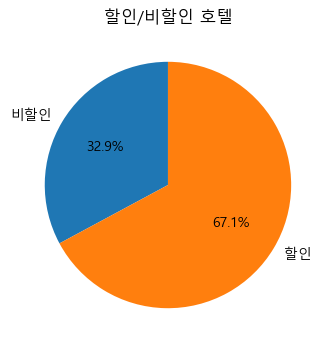

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

ho1 = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8-sig')
ho = pd.DataFrame(ho1)

ho['할인유무'] = ho['discount'].map({
    1: '할인',
    0: '비할인',
})

result = ho.groupby('할인유무')['h_code'].count().reset_index()
result
# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (4,4))

# plt.bar(result['할인유무'], result['h_code'], width=0.2, color='dodgerblue')

plt.pie(
    result['h_code'],
    labels=result['할인유무'],
    autopct='%1.1f%%',
    startangle=90
)

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("할인/비할인 호텔")
# plt.xlabel("할인, 비할인")
# plt.ylabel("호텔수")

할인중인 호텔 예약률, 비할인 호텔 예약률 → 원형

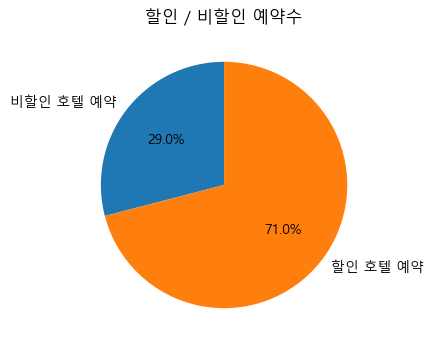

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

re1 = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
re = pd.DataFrame(re1) 

re['할인/비할인 예약'] = re['discount_rate'].map({
    10: '할인 호텔 예약',
    0: '비할인 호텔 예약',
})

result = re.groupby('할인/비할인 예약')['re_code'].count().reset_index()

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (4,4))

plt.pie(
    result['re_code'],
    labels=result['할인/비할인 예약'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('할인 / 비할인 예약수')

plt.show()


월별 매출 - 막대 그래프 - reservation / join 필요없음

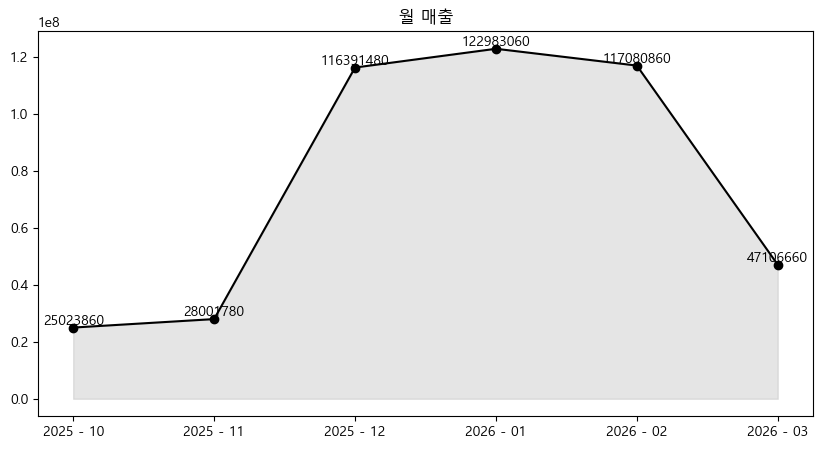

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

re = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
re1 = pd.DataFrame(re) 
re1 = re1[re1['cancel'] == 0]
re1
# 날짜형식으로 변경
re1['reserved_at'] = pd.to_datetime(re1['reserved_at'])

re1['예약날짜'] = re1['reserved_at'].dt.strftime('%Y - %m')
result = re1.groupby('예약날짜')['final_price'].sum().reset_index()

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,5))

plt.plot(result['예약날짜'], result['final_price'], marker='o', color='black')
plt.fill_between(result['예약날짜'], result['final_price'], alpha = 0.3, color = '#aaa')

for i in range(len(result)):
    v = result['final_price'][i]
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v,             # y의 위치 (막대 높이) 
        int(v),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("월 매출")

plt.show()

In [ ]:
분기별 매출 - 막대 그래프 - reservation / join 필요없음

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

re = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
re1 = pd.DataFrame(re) 
re1 = re1[re1['cancel'] == 0]
re1
# 날짜형식으로 변경
re1['reserved_at'] = pd.to_datetime(re1['reserved_at'])

if 
    re1['분기'] = re1['reserved_at'].dt.strftime('%Y-%m')
result = re1.groupby('분기')['final_price'].sum().reset_index()

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,5))

plots = plt.plot(result['예약날짜'], result['final_price'], marker = 'o', color = 'black')
plt.fill_between(result['예약날짜'], result['final_price'], alpha = 0.3, color = '#aaa')

for i in range(len(result)):
    v = result['final_price'][i]
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v,             # y의 위치 (막대 높이) 
        int(v),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("연 매출")
plt.xlabel("연도")
plt.ylabel("매출")

plt.show()

연 매출 - 막대 그래프 - reservation / join 필요없음

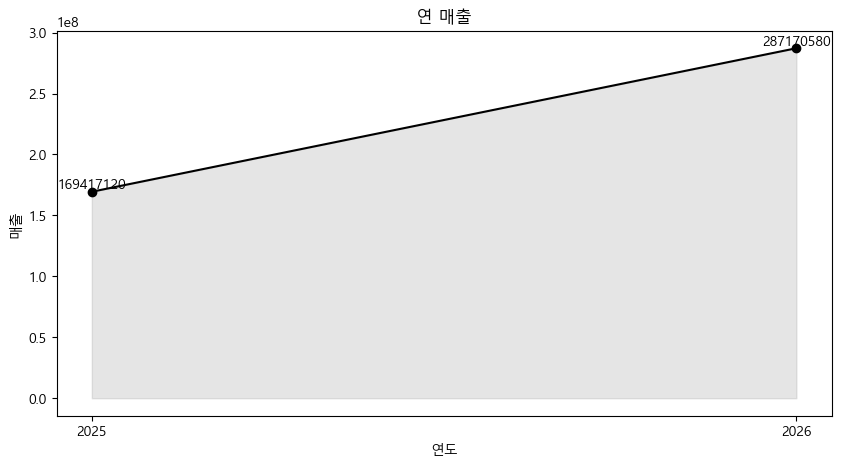

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

re = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
re1 = pd.DataFrame(re) 
re1 = re1[re1['cancel'] == 0]
re1
# 날짜형식으로 변경
re1['reserved_at'] = pd.to_datetime(re1['reserved_at'])

re1['예약날짜'] = re1['reserved_at'].dt.strftime('%Y')
result = re1.groupby('예약날짜')['final_price'].sum().reset_index()

# -------------------------------------
# 반드시 한극 깨짐 현상 코드 삽입
# -------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize= (10,5))

plots = plt.plot(result['예약날짜'], result['final_price'], marker = 'o', color = 'black')
plt.fill_between(result['예약날짜'], result['final_price'], alpha = 0.3, color = '#aaa')

for i in range(len(result)):
    v = result['final_price'][i]
    plt.text(
        i,             # x의 위치 (막대 위치 : 0, 1, 2 ~)
        v,             # y의 위치 (막대 높이) 
        int(v),        # 정수로 표시할 값
        ha='center',
        va='bottom',
    )

# 차트 제목, 가로축 제목, 세로축 제목 지정
plt.title("연 매출")
plt.xlabel("연도")
plt.ylabel("매출")

plt.show()